# Assigning Parcel Labels to Brain Vertices via MNI-Space Atlases

## Overview

Neuroimaging atlases — parcellations that divide the cerebral cortex into anatomically
or functionally defined regions — are a cornerstone of group-level fNIRS and DOT
analysis. Atlases allow researchers to:

* Report results in a standardised anatomical vocabulary that is comparable across
  studies and laboratories.
* Aggregate channel or vertex signals into region-of-interest (ROI) time series,
  reducing the multiple-comparisons burden.
* Cross-reference DOT activations with the large fMRI literature, where the same
  atlas labels are widely used.

### MNI space as a shared coordinate system

Most brain atlases are defined and distributed in **MNI (Montreal Neurological
Institute) space**: a standardised brain coordinate frame derived from averaging many
individual MRI scans into a common template.
Every standard head model in Cedalion — Colin27
<cite data-cite="Holmes1998">(Holmes et al., 1998)</cite>
and ICBM152
<cite data-cite="Fonov2011">(Fonov et al., 2011)</cite> — carries pre-computed MNI152
coordinates for every brain surface vertex. This means that **any** volumetric atlas
provided as a NIfTI file in MNI space can be transferred to the brain surface without
any additional registration step: the shared coordinate system acts as the bridge
between the volumetric atlas and the surface model.

### The two MNI spaces: MNI152 and MNI305

Two MNI variants are in common use and it is important to keep them distinct:

| Space | Template | Typical users |
|---|---|---|
| **MNI152** | Average of 152 adult brains (ICBM152 template) | FSL, recent SPM, most modern atlases |
| **MNI305** | Average of 305 brains; the original MNI reference | FreeSurfer, older SPM, some legacy atlases |

MNI152 and MNI305 differ by a small affine shift (a few millimetres in some regions)
and are **not** interchangeable. Cedalion stores a pre-computed affine transform
(`cedalion.dot.utils.mni305_to_mni152`) and applies it automatically when a NIfTI is
declared as `voxel_label_crs='mni305'`, so you do not need to handle the conversion
manually. Both spaces are fully supported; you simply specify which one your NIfTI
file uses.

### What this notebook demonstrates

This notebook shows the general workflow for applying **any** user-supplied parcellation
scheme — provided as a NIfTI label volume in either MNI152 or MNI305 space — to the
Cedalion head models. The workflow is illustrated with two widely used atlases:

* **AAL3** (Automated Anatomical Labelling atlas, version 3)
  <cite data-cite="Rolls2020">(Rolls et al., 2020)</cite> — 170 macro-anatomical regions
  covering the entire cerebral cortex and subcortex.
* **Brodmann areas** (Mai–Majtanik atlas)
  <cite data-cite="Mai2017">(Mai & Majtanik, 2017)</cite> — the classical cytoarchitectonic
  map, available as a volumetric MNI label file.

Both atlases are bundled with Cedalion and loaded via `cedalion.data.get_atlas_files()`.
The same code applies unchanged to any other NIfTI atlas you supply.

**For more detail, see also:**
- [43a_head_models_overview.ipynb](43a_head_models_overview.ipynb) — introduction to
  `TwoSurfaceHeadModel` and the Schaefer2018 parcellation bundled with the standard models
- [43b_individualized_head_models.ipynb](43b_individualized_head_models.ipynb) — building an
  individualized head model from a subject's own MRI using FreeSurfer, which yields
  surface-native parcel labels with sharper boundaries than the volumetric approach shown here

In [1]:
import json

import numpy as np
import pyvista as pv
from scipy.spatial import KDTree

import cedalion
import cedalion.dot
from cedalion.vis.anatomy import get_vertex_colors_from_coord, plot_brain_views_grid

pv.set_jupyter_backend("static")

## Loading Colin27 and ICBM152 Head Models

We load both standard atlas head models. Each is stored in voxel space (`crs='ijk'`);
`assign_parcels_via_mni_coords` works in MNI152 space internally so the coordinate
system of the loaded head model does not need to match that of the atlas.

Both models carry pre-computed `mni152_r/a/s` vertex coordinates on the brain surface,
which is what makes the atlas transfer possible. The inflated cortex surfaces are loaded
for visualization: inflation removes sulci and gyri so that buried cortex becomes
visible, making parcel boundaries much easier to inspect.

In [2]:
colin_ijk = cedalion.dot.get_standard_headmodel("colin27")
colin_inflated = cedalion.dot.get_inflated_cortex_surface("colin27")

icbm_ijk = cedalion.dot.get_standard_headmodel("icbm152")
icbm_inflated = cedalion.dot.get_inflated_cortex_surface("icbm152")

## Loading Atlases

Atlases distributed for use with standard MNI templates typically come in two files:

1. A **NIfTI volume** (`.nii` or `.nii.gz`) in which every voxel inside a labelled
   region carries a positive integer, and background voxels carry 0 (or another
   reserved value).
2. A **label mapping** (`.json`, `.csv`, or `.txt`) that translates those integers to
   human-readable region names.

`cedalion.data.get_atlas_files(name)` returns both paths for the bundled atlases.
For a custom atlas you can pass any NIfTI path you have downloaded or created.

### AAL3 — Automated Anatomical Labelling atlas (version 3)

AAL3 <cite data-cite="Rolls2020">(Rolls et al., 2020)</cite> divides the cerebral cortex
and subcortical structures into 170 macro-anatomical regions based on sulcal and gyral
landmarks visible in the MNI152 template. It is one of the most widely used atlases in
the fMRI and fNIRS literature and provides a common vocabulary for reporting results.
The NIfTI file bundled with Cedalion is defined in **MNI152** space.

In [3]:
aal3_voxel_label_niftii, aal3_labels_json = cedalion.data.get_atlas_files("aal3")

# dictionary to map numeric voxel labels in nifti to string labels
with aal3_labels_json.open("r") as fin:
    aal3_num2label = json.load(fin)
    aal3_num2label = {i["index"] : i["name"] for i in aal3_num2label["labels"]}

aal3_num2label

Unzipping contents of 'C:\Users\mayucel\AppData\Local\cedalion\cedalion\Cache\dev\atlas_aal3.zip' to 'C:\Users\mayucel\AppData\Local\cedalion\cedalion\Cache\dev\atlas_aal3.zip.unzip'


{1: 'Precentral_L',
 2: 'Precentral_R',
 3: 'Frontal_Sup_2_L',
 4: 'Frontal_Sup_2_R',
 5: 'Frontal_Mid_2_L',
 6: 'Frontal_Mid_2_R',
 7: 'Frontal_Inf_Oper_L',
 8: 'Frontal_Inf_Oper_R',
 9: 'Frontal_Inf_Tri_L',
 10: 'Frontal_Inf_Tri_R',
 11: 'Frontal_Inf_Orb_2_L',
 12: 'Frontal_Inf_Orb_2_R',
 13: 'Rolandic_Oper_L',
 14: 'Rolandic_Oper_R',
 15: 'Supp_Motor_Area_L',
 16: 'Supp_Motor_Area_R',
 17: 'Olfactory_L',
 18: 'Olfactory_R',
 19: 'Frontal_Sup_Medial_L',
 20: 'Frontal_Sup_Medial_R',
 21: 'Frontal_Med_Orb_L',
 22: 'Frontal_Med_Orb_R',
 23: 'Rectus_L',
 24: 'Rectus_R',
 25: 'OFCmed_L',
 26: 'OFCmed_R',
 27: 'OFCant_L',
 28: 'OFCant_R',
 29: 'OFCpost_L',
 30: 'OFCpost_R',
 31: 'OFClat_L',
 32: 'OFClat_R',
 33: 'Insula_L',
 34: 'Insula_R',
 37: 'Cingulate_Mid_L',
 38: 'Cingulate_Mid_R',
 39: 'Cingulate_Post_L',
 40: 'Cingulate_Post_R',
 41: 'Hippocampus_L',
 42: 'Hippocampus_R',
 43: 'ParaHippocampal_L',
 44: 'ParaHippocampal_R',
 45: 'Amygdala_L',
 46: 'Amygdala_R',
 47: 'Calcarine_L',
 

### Brodmann Areas — Mai–Majtanik Atlas

Brodmann areas are the classical cytoarchitectonic map of the human cortex, originally
defined by Korbinian Brodmann in 1909 from histological sections and still widely used
to communicate the location of activations in the neuroscience literature. The
Mai–Majtanik atlas <cite data-cite="Mai2017">(Mai & Majtanik, 2017)</cite> provides
these areas as a digitised volumetric label map registered to **MNI152** space, making
it directly compatible with the Cedalion head models. Areas such as BA44/45
(Broca's area) or BA17 (primary visual cortex) are convenient reference landmarks when
linking fNIRS results to the broader neuroimaging literature.

In [4]:
brodmann_voxel_label_niftii, brodmann_labels_json = cedalion.data.get_atlas_files("brodmann")

# dictionary to map numeric voxel labels in nifti to string labels
with brodmann_labels_json.open("r") as fin:
    brodmann_num2label = json.load(fin)
    brodmann_num2label = {i["index"] : i["name"] for i in brodmann_num2label["labels"]}

brodmann_num2label

Unzipping contents of 'C:\Users\mayucel\AppData\Local\cedalion\cedalion\Cache\dev\atlas_brodmann.zip' to 'C:\Users\mayucel\AppData\Local\cedalion\cedalion\Cache\dev\atlas_brodmann.zip.unzip'


{1: 'right_Ent',
 2: 'right_BA20',
 3: 'right_BA38',
 4: 'right_BA21',
 5: 'right_BA36',
 6: 'right_BA11',
 7: 'right_BA37',
 8: 'right_BA25',
 9: 'right_BA12',
 10: 'right_BA19',
 11: 'right_BA47',
 12: 'right_BA22',
 13: 'right_BA18',
 14: 'right_BA10',
 15: 'right_BA17',
 16: 'right_BA32',
 17: 'right_BA24',
 18: 'right_BA46',
 19: 'right_BA45',
 20: 'right_BA33',
 21: 'right_BA44',
 22: 'right_BA6',
 23: 'right_BA23',
 24: 'right_BA42',
 25: 'right_BA43',
 26: 'right_BA30',
 27: 'right_BA41',
 28: 'right_BA29',
 29: 'right_BA26',
 30: 'right_BA31',
 31: 'right_BA4',
 32: 'right_BA1',
 33: 'right_BA9',
 34: 'right_BA39',
 35: 'right_BA2',
 36: 'right_BA3',
 37: 'right_BA40',
 38: 'right_BA7',
 39: 'right_BA8',
 40: 'right_BA5',
 41: 'right_BA52',
 42: 'right_BA35',
 43: 'right_BA34',
 101: 'left_Ent',
 102: 'left_BA20',
 103: 'left_BA38',
 104: 'left_BA21',
 105: 'left_BA36',
 106: 'left_BA11',
 107: 'left_BA37',
 108: 'left_BA25',
 109: 'left_BA12',
 110: 'left_BA19',
 111: 'left_B

## Brain Vertex Coordinates Before Atlas Assignment

The `brain.vertices` xarray `DataArray` already carries several vertex coordinates set
when the head model was built from FreeSurfer outputs:

| Coordinate | Meaning |
|---|---|
| `parcel` | Schaefer2018 parcel label <cite data-cite="Schaefer2018">(Schaefer et al., 2018)</cite> |
| `fsaverage_vertex` | Corresponding vertex index in the FreeSurfer `fsaverage` template |
| `mni152_r/a/s` | MNI152 RAS coordinates of the vertex in mm |

Calling `assign_parcels_via_mni_coords` will **add** a new named coordinate to this
`DataArray` without removing or modifying any existing one. Multiple atlas labels can
therefore coexist on the same vertex, which is what we exploit below.

In [5]:
colin_ijk.brain.vertices

Magnitude,[[82.522325 19.841515 68.313221] [83.516588 20.319351 65.886337] [78.524571 20.543388 63.648142] ... [127.025612 152.660339 99.546274] [96.280465 105.252083 86.734898] [127.619801 34.463676 60.37505]]
Units,dimensionless


## Assigning Atlas Labels to Brain Vertices

`TwoSurfaceHeadModel.assign_parcels_via_mni_coords` transfers labels from a volumetric
NIfTI atlas to the brain surface by exploiting the MNI152 coordinates shared by both.
The algorithm works as follows:

1. **Coordinate alignment**: The NIfTI affine transform is used to compute the MNI
   coordinate of every voxel centre. If the atlas is in MNI305 space
   (`voxel_label_crs='mni305'`), the pre-computed affine
   `cedalion.dot.utils.mni305_to_mni152` is applied first to bring voxel coordinates
   into the same MNI152 frame as the head model vertices.

2. **Nearest-labelled-voxel search**: A KD-tree is built from the voxel centres. For
   each brain surface vertex, all voxels within a ball of radius `mni_eps` mm in MNI152
   space are retrieved. Background voxels (label 0 or whichever integer maps to
   `background_label`) are excluded, and the closest *labelled* voxel is selected.

3. **Label assignment**: The integer label of the winning voxel is translated to a
   string via `label_mapping` and stored as a new vertex coordinate. If no labelled
   voxel falls within `mni_eps` mm, the vertex receives `background_label`.

**Key parameters:**

| Parameter | Effect |
|---|---|
| `coordinate_label` | Name of the new vertex coordinate (e.g. `'parcel_aal3'`) |
| `label_mapping` | `{int: str}` dict mapping numeric voxel labels to region names |
| `voxel_label_niftii` | Path to the NIfTI atlas file |
| `voxel_label_crs` | MNI variant of the NIfTI: `'mni152'` (default) or `'mni305'` |
| `mni_eps` | Search radius in mm (default `5`). Increase if many vertices receive `'Background'` |

Each call returns a **new** head model object; the original is not modified
(immutable-style API). We chain two calls to assign both atlases in sequence.

Assigning AAL3 and Brodmann labels to the Colin27 head:

In [6]:
# Colin27

colin_ijk_labeled = colin_ijk.assign_parcels_via_mni_coords(
    coordinate_label="parcel_aal3",
    label_mapping=aal3_num2label,
    voxel_label_niftii=aal3_voxel_label_niftii,
    voxel_label_crs="mni152",
    mni_eps=5
)

colin_ijk_labeled = colin_ijk_labeled.assign_parcels_via_mni_coords(
    coordinate_label="parcel_brodmann",
    label_mapping=brodmann_num2label,
    voxel_label_niftii=brodmann_voxel_label_niftii,
    voxel_label_crs="mni152",
    mni_eps=5
)


colin_ijk_labeled.brain.vertices

Magnitude,[[82.522325 19.841515 68.313221] [83.516588 20.319351 65.886337] [78.524571 20.543388 63.648142] ... [127.025612 152.660339 99.546274] [96.280465 105.252083 86.734898] [127.619801 34.463676 60.37505]]
Units,dimensionless


Because ICBM152 and Colin27 share the same MNI152 coordinate frame, the *identical*
NIfTI atlas files and label dictionaries work unchanged for both head models. This
is the practical benefit of the shared coordinate system: you write the atlas assignment
code once and it applies to any head model that has MNI152 vertex coordinates.

Assigning AAL3 and Brodmann labels to the ICBM152 head:

In [7]:
# ICBM-152

icbm_ijk_labeled = icbm_ijk.assign_parcels_via_mni_coords(
    coordinate_label="parcel_aal3",
    label_mapping=aal3_num2label,
    voxel_label_niftii=aal3_voxel_label_niftii,
    voxel_label_crs="mni152",
    mni_eps=5
)

icbm_ijk_labeled = icbm_ijk_labeled.assign_parcels_via_mni_coords(
    coordinate_label="parcel_brodmann",
    label_mapping=brodmann_num2label,
    voxel_label_niftii=brodmann_voxel_label_niftii,
    voxel_label_crs="mni152",
    mni_eps=5
)


icbm_ijk_labeled.brain.vertices

Magnitude,[[81.244216 26.627602 150.621031] [81.577181 27.302513 157.143576] [77.826448 27.459724 154.566914] ... [118.580717 84.619659 208.0373] [143.100407 63.906384 138.08789] [133.577629 151.8062 150.919106]]
Units,dimensionless


## Plotting Parcellation Schemes

Cedalion's surface plotting functions accept a list of per-vertex colors (RGB tuples
or matplotlib color specs), one entry per vertex in vertex order. The helper
`cedalion.vis.anatomy.get_vertex_colors_from_coord` builds this list from a named
vertex coordinate and a `color_mapping` that translates string labels to colors.

Three `color_mapping` modes are supported:

| `color_mapping` value | Behaviour |
|---|---|
| `dict` (label → color) | Each label is looked up; vertices not in the dict get `default_color` |
| `None` | A random but deterministic color is generated for every unique label |
| A single color string (e.g. `'r'`) | Every vertex whose label is in `labels` gets that color; the rest get `default_color` |

We first demonstrate with the **Schaefer2018** parcellation that is bundled with the
head model and has an official color map:

In [8]:
# example: Schaefer parcel colors
schaefer_color_dict = cedalion.data.get_colin27_headmodel_files().load_parcel_colors()
display(schaefer_color_dict)

{'VisCent_Striate_1_LH': [120, 18, 135],
 'VisCent_Striate_2_LH': [120, 18, 136],
 'VisCent_Striate_3_LH': [120, 18, 137],
 'VisCent_ExStr_1_LH': [120, 18, 128],
 'VisCent_ExStr_2_LH': [120, 18, 129],
 'VisCent_ExStr_3_LH': [120, 18, 130],
 'VisCent_ExStr_4_LH': [120, 18, 131],
 'VisCent_ExStr_5_LH': [120, 18, 132],
 'VisCent_ExStr_6_LH': [120, 18, 133],
 'VisCent_ExStr_7_LH': [120, 18, 134],
 'VisCent_ExStr_8_LH': [120, 18, 138],
 'VisCent_ExStr_9_LH': [120, 18, 139],
 'VisCent_ExStr_10_LH': [120, 18, 140],
 'VisCent_ExStr_11_LH': [120, 18, 141],
 'VisCent_ExStr_12_LH': [120, 18, 142],
 'VisCent_ExStr_13_LH': [120, 19, 135],
 'VisCent_ExStr_14_LH': [120, 19, 136],
 'VisCent_ExStr_15_LH': [120, 19, 137],
 'VisCent_ExStr_16_LH': [120, 19, 138],
 'VisCent_ExStr_17_LH': [120, 19, 139],
 'VisPeri_StriCal_1_LH': [255, 0, 1],
 'VisPeri_StriCal_2_LH': [255, 0, 2],
 'VisPeri_StriCal_3_LH': [255, 0, 3],
 'VisPeri_StriCal_4_LH': [255, 0, 4],
 'VisPeri_StriCal_5_LH': [255, 0, 5],
 'VisPeri_ExStrI

`get_vertex_colors_from_coord` iterates over every brain surface vertex, reads its
label from the named coordinate, and returns the corresponding color from the mapping.
Vertices whose label is not found in the mapping receive `default_color` (grey by
default). The result is a list in the same vertex order as `brain.vertices`, ready to
pass directly to any of the `cedalion.vis` plotting functions.

In [9]:
vertex_colors = get_vertex_colors_from_coord(colin_ijk_labeled.brain, "parcel", color_mapping=schaefer_color_dict)
print(f"The brain surface has {colin_ijk_labeled.brain.nvertices} vertices.")
print(f"The list vertex_colors has {len(vertex_colors)} entries. These are the first entries:")
vertex_colors[:4]

The brain surface has 25000 vertices.
The list vertex_colors has 25000 entries. These are the first entries:


[(0.47058823529411764, 0.07058823529411765, 0.5411764705882353),
 (0.47058823529411764, 0.07058823529411765, 0.5333333333333333),
 (0.47058823529411764, 0.07058823529411765, 0.5411764705882353),
 (0.47058823529411764, 0.07058823529411765, 0.5411764705882353)]

`plot_brain_views_grid` renders the brain surface from five standard viewpoints
(superior, left, right, anterior, posterior) in a single figure.
We pass the **inflated** surface here — which has the same vertex order as the pial
surface — so sulcal cortex is unfolded and every parcel is visible at once.

The Schaefer2018 parcellation on the inflated Colin27 cortex:

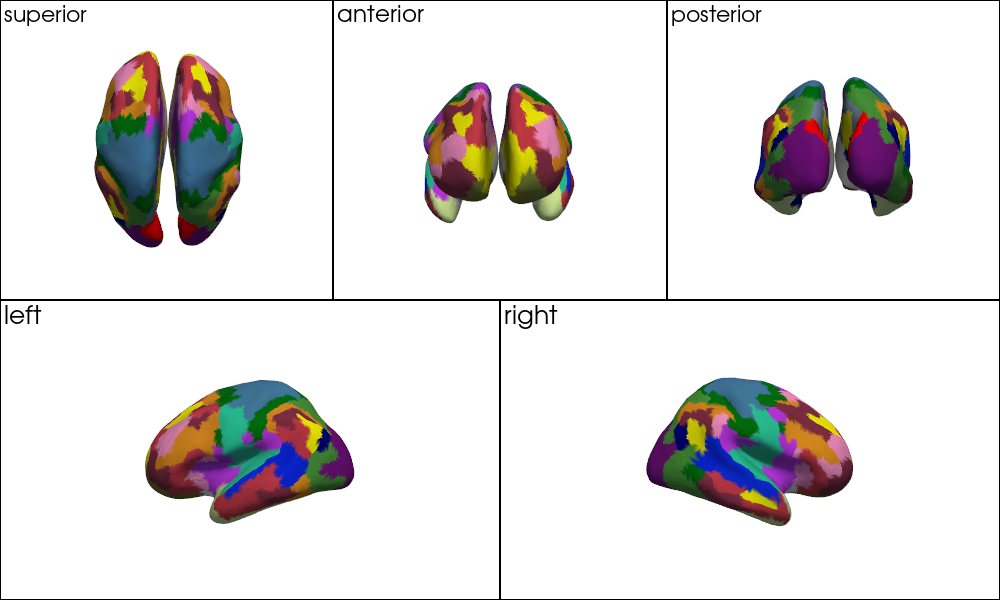

In [10]:
plot_brain_views_grid(colin_inflated, vertex_colors, reset_camera=True)

### AAL3 Labels on Colin27

We now visualize the freshly assigned AAL3 labels. Because AAL3 does not ship with a
canonical per-region color map, we pass `color_mapping=None` to let
`get_vertex_colors_from_coord` generate colors automatically. The algorithm uses a
deterministic golden-ratio hue spacing so colors are consistent across calls.

We show both the **pial** (folded) and the **inflated** surface. The inflated view
makes buried sulcal cortex visible and allows you to judge where parcel boundaries
fall relative to major anatomical landmarks. Notice that compared to the Schaefer2018
map above, some AAL3 borders appear slightly less crisp — this is the expected
consequence of the volumetric-to-surface transfer (discussed in detail at the end
of this notebook).

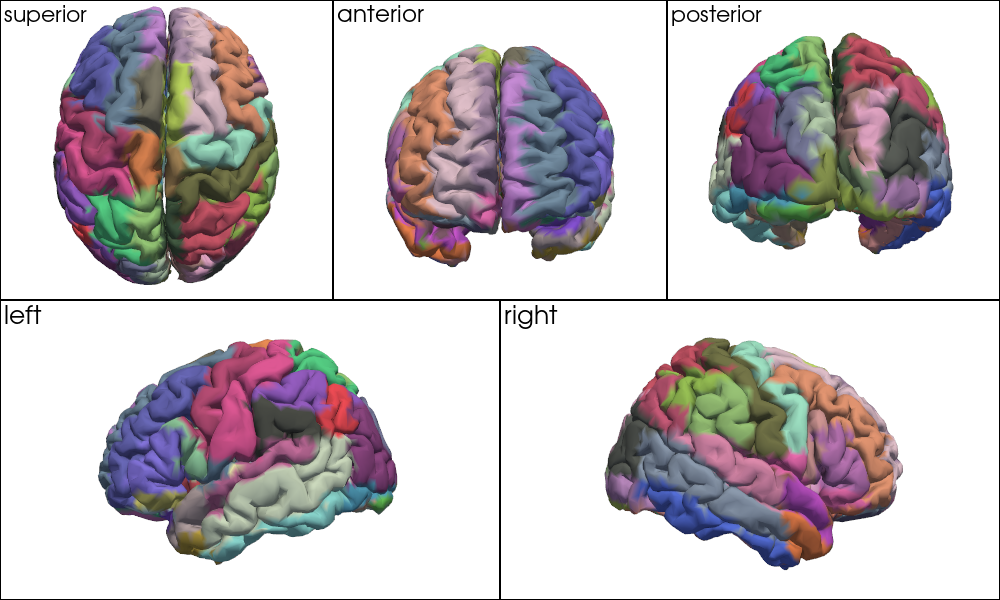

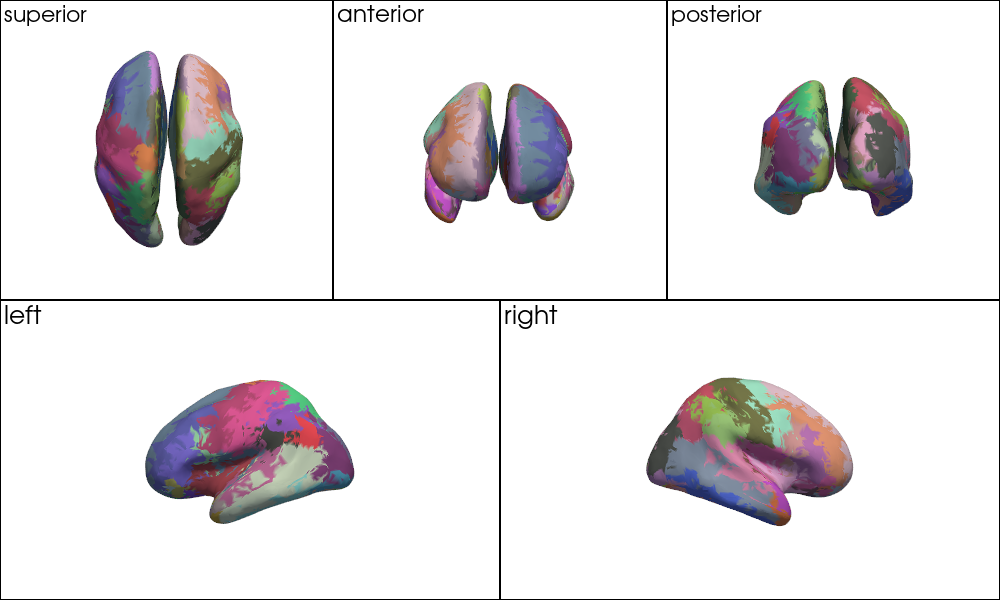

In [11]:
vertex_colors = get_vertex_colors_from_coord(colin_ijk_labeled.brain, "parcel_aal3", color_mapping=None, default_color="magenta")

plot_brain_views_grid(colin_ijk_labeled.brain, vertex_colors)
plot_brain_views_grid(colin_inflated, vertex_colors, reset_camera=True)

### Brodmann Labels on Colin27

The same workflow applied to the Brodmann atlas. Brodmann areas are fewer and larger
than AAL3 regions. On the inflated surface the classical areas are clearly recognisable:
BA4/6 along the central sulcus (motor/premotor), BA17/18/19 in the occipital lobe
(visual cortex), and BA44/45 in the left inferior frontal gyrus (Broca's area).

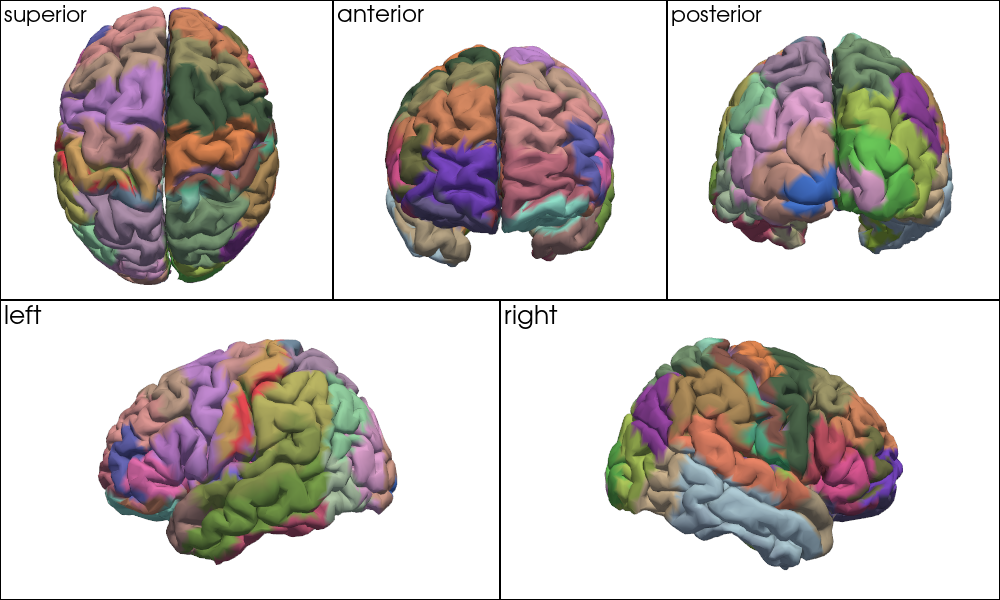

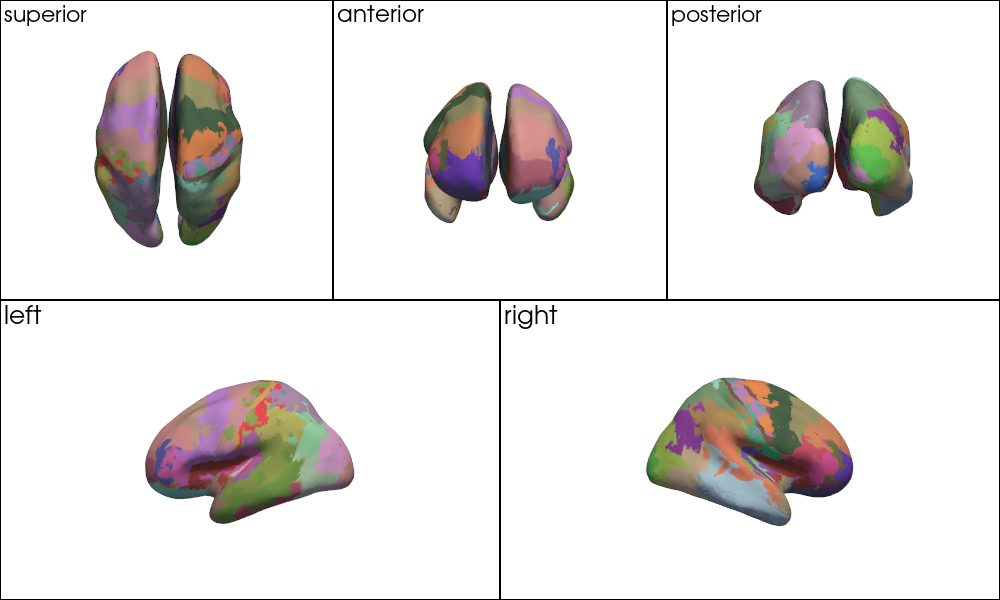

In [12]:
vertex_colors = get_vertex_colors_from_coord(colin_ijk_labeled.brain, "parcel_brodmann", color_mapping=None)

plot_brain_views_grid(colin_ijk_labeled.brain, vertex_colors)
plot_brain_views_grid(colin_inflated, vertex_colors, reset_camera=True)

### AAL3 Labels on ICBM152

The same atlas applied to the ICBM152 head model. Any differences from the Colin27
result reflect genuine anatomical differences between the two templates (single-subject
average vs. group average) rather than any difference in the atlas or the transfer
procedure.

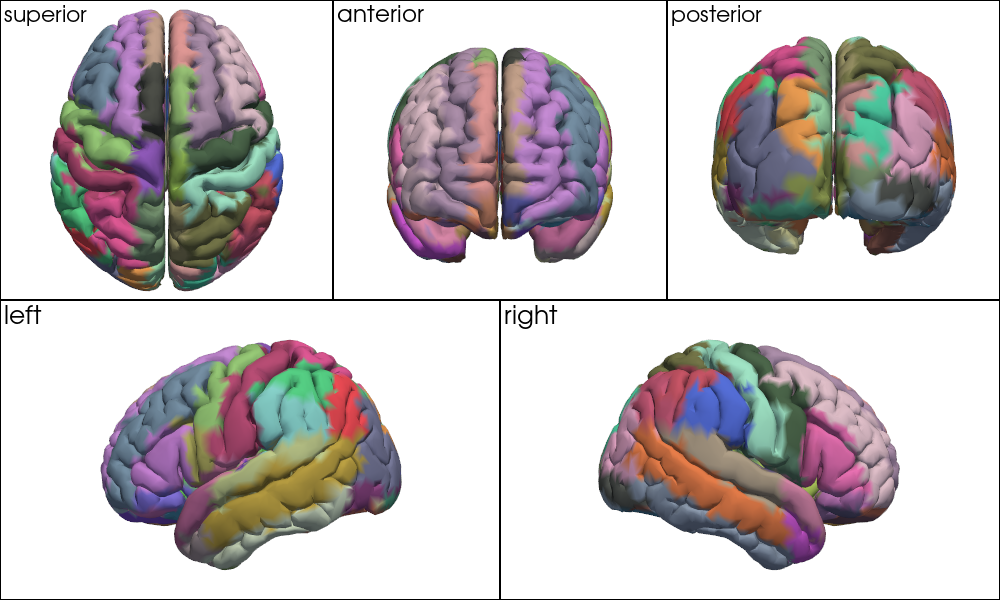

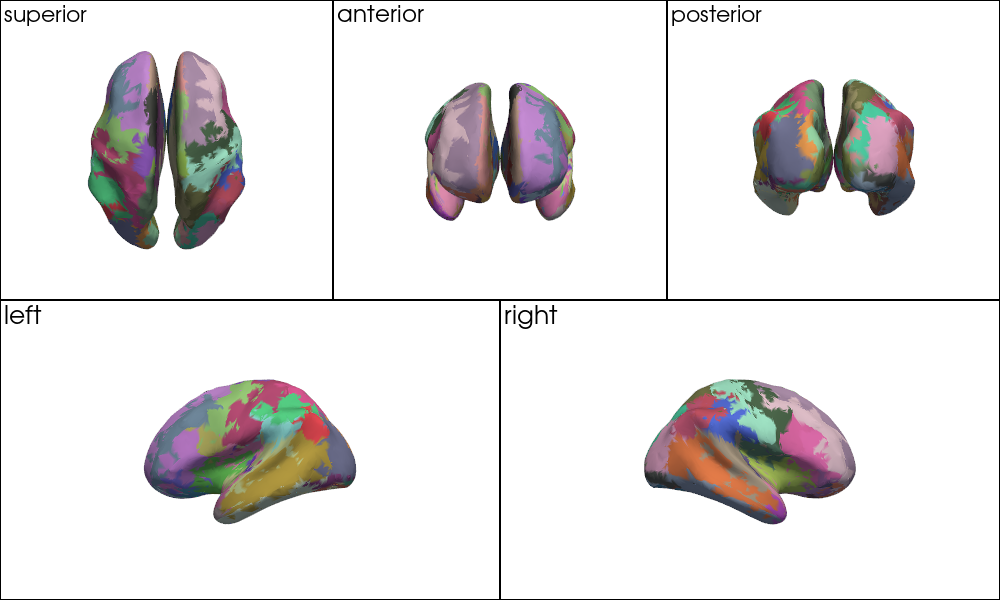

In [13]:
vertex_colors = get_vertex_colors_from_coord(icbm_ijk_labeled.brain, "parcel_aal3", color_mapping=None)

plot_brain_views_grid(icbm_ijk_labeled.brain, vertex_colors)
plot_brain_views_grid(icbm_inflated, vertex_colors, reset_camera=True)

### Brodmann Labels on ICBM152

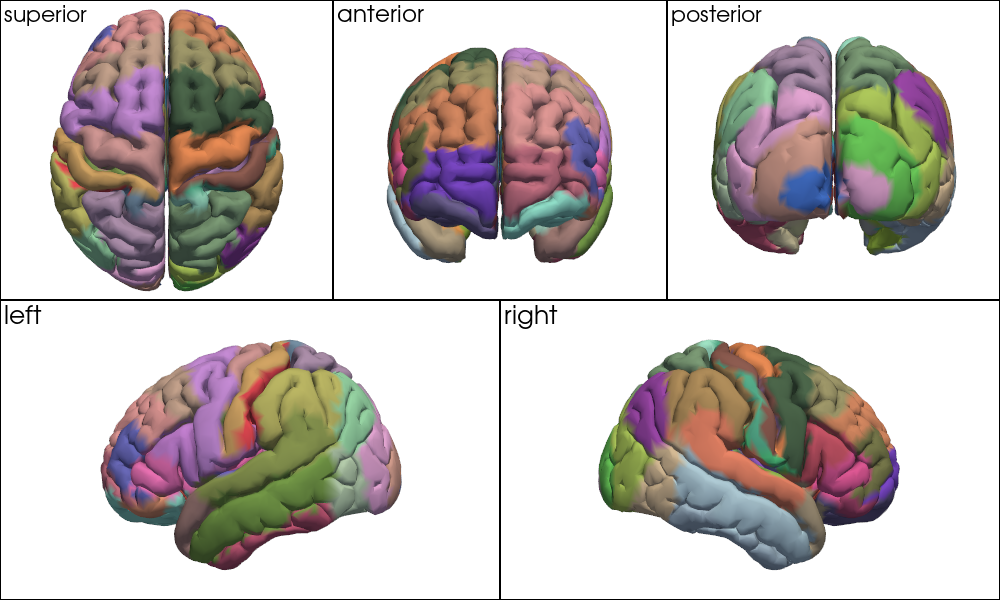

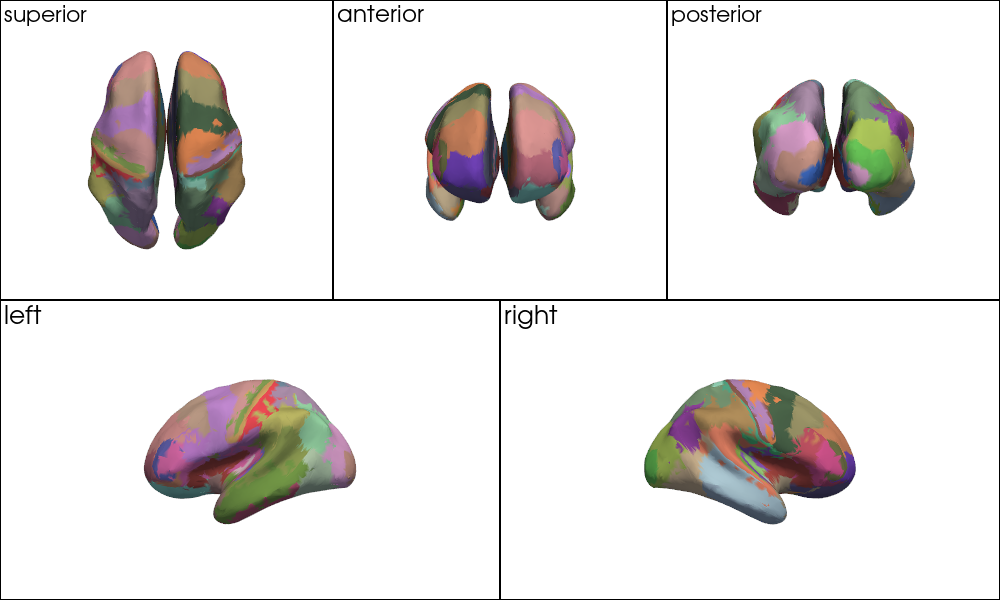

In [14]:
vertex_colors = get_vertex_colors_from_coord(icbm_ijk_labeled.brain, "parcel_brodmann", color_mapping=None)

plot_brain_views_grid(icbm_ijk_labeled.brain, vertex_colors)
plot_brain_views_grid(icbm_inflated, vertex_colors, reset_camera=True)

## Customizing Colors for ROI Highlighting

In practice you will often want to highlight a small set of regions of interest rather
than visualize the entire atlas at once. `get_vertex_colors_from_coord` supports two
convenience patterns for this.

**Pattern 1 — selected parcels with distinct colors:**

Pass a partial `color_mapping` dict containing only the regions you care about. All
other vertices receive `default_color` (grey). Use this when the highlighted regions
should be distinguished from one another by color — for example when comparing two
adjacent AAL3 frontal regions.

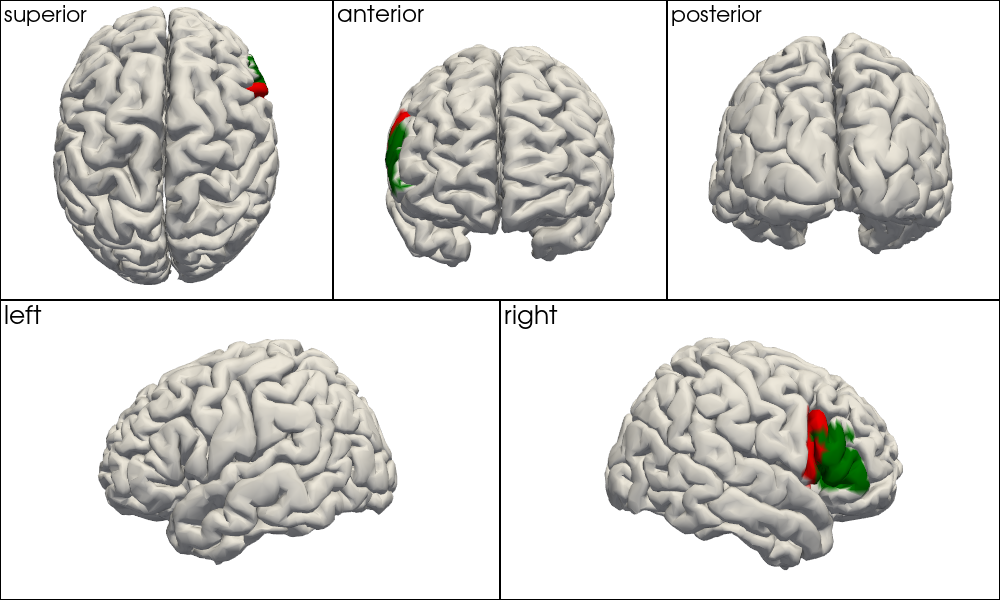

In [15]:
# select only two parcels and specify colors (any matplotlib color spec works)
# parcels not contained in the mapping get the default color
aal3_color_mapping = {"Frontal_Inf_Oper_R" : "r", "Frontal_Inf_Tri_R" : "g"}

vertex_colors = get_vertex_colors_from_coord(colin_ijk_labeled.brain, "parcel_aal3", aal3_color_mapping)
plot_brain_views_grid(colin_ijk_labeled.brain, vertex_colors)


**Pattern 2 — highlight a set of parcels in a single color:**

Pass a single color string as `color_mapping` and provide a `labels` list. Every
vertex whose coordinate matches a label in the list gets the specified color; all
other vertices get `default_color`. This gives the clearest signal-vs-background
contrast when you want to show, for example, bilateral Broca's area (BA44 + BA45)
against a neutral grey background.

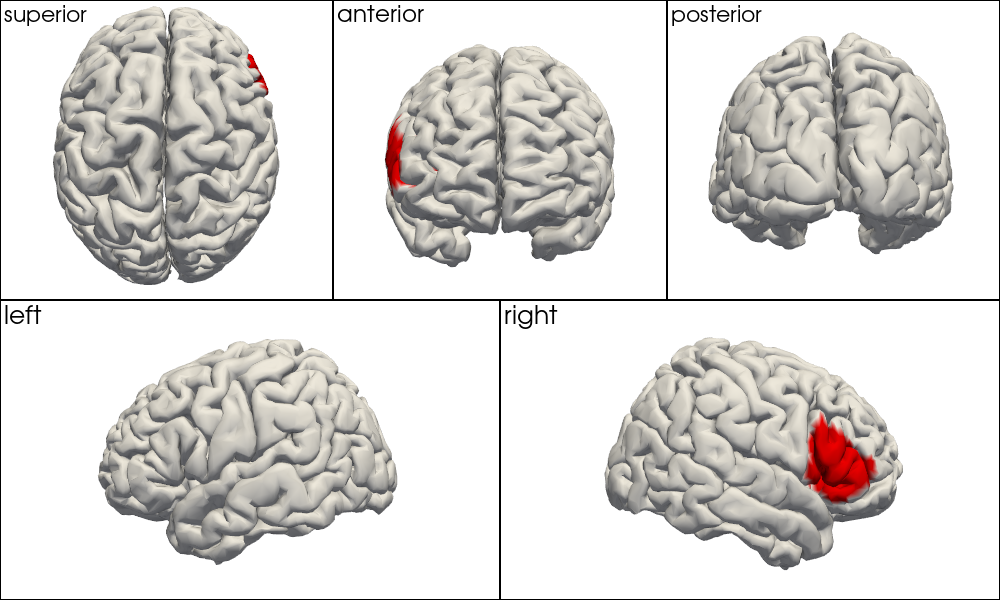

In [16]:
# specify only a single color, that will be used for all parcels. Then select only a subset of parcels to color.

vertex_colors = get_vertex_colors_from_coord(
    colin_ijk_labeled.brain,
    "parcel_brodmann",
    color_mapping="r",
    labels=["right_BA44", "right_BA45"],
)
plot_brain_views_grid(colin_ijk_labeled.brain, vertex_colors)

## Spot-Check: Verifying Label Assignments at Known MNI Coordinates

As a sanity check we verify that the assigned labels are anatomically plausible at
three well-known MNI152 locations. We find the nearest brain surface vertex in MNI152
space and read off its Brodmann label.

| MNI coordinate | Expected region |
|---|---|
| `[-10, -90, 0]` | Occipital pole / calcarine sulcus (BA17/18) |
| `[-40, -20, 50]` | Left somatomotor cortex (BA4/6) |
| `[ 40,  20, 30]` | Right prefrontal cortex (BA44/45/46) |

In [17]:
tests = np.asarray([
    [-10, -90, 0],
    [-40, -20, 50],
    [40, 20, 30],
], dtype=float)

vertex_coords = icbm_ijk_labeled.get_brain_mni152_coords().pint.dequantify().values
vertex_labels = icbm_ijk_labeled.brain.vertices.coords["parcel_brodmann"].values
_, nearest = KDTree(vertex_coords).query(tests)

for mni, vertex_idx in zip(tests, nearest):
    print(f"MNI {mni.tolist()} -> nearest surface label {vertex_labels[vertex_idx]}")

MNI [-10.0, -90.0, 0.0] -> nearest surface label left_BA17
MNI [-40.0, -20.0, 50.0] -> nearest surface label left_BA3
MNI [40.0, 20.0, 30.0] -> nearest surface label right_BA44


## Parcel-Level Summary Tables

`TwoSurfaceHeadModel.parcel_summary_from_vertex_coordinate` converts the per-vertex
atlas labels into a compact table with **one row per Schaefer2018 parcel** (the
parcellation bundled with the head model). For each Schaefer parcel it reports:

| Column | Meaning |
|---|---|
| `atlas_label` | Dominant atlas region covering that parcel (plurality vote over vertices) |
| `matching_vertices` | Number of vertices whose atlas label equals `atlas_label` |
| `parcel_vertices` | Total number of vertices in the Schaefer parcel |
| `fraction_of_parcel` | Coverage fraction (`matching_vertices / parcel_vertices`) |
| `mni152_r/a/s` | MNI152 centroid of a representative vertex from that parcel |

Medial-wall and background parcels are excluded by default because they do not
correspond to cortical tissue. The function returns a `pandas.DataFrame` that can be
saved with `.to_csv(..., sep='\t')` for use in downstream analyses or supplementary
tables in manuscripts.

In [18]:
colin_ijk_labeled.parcel_summary_from_vertex_coordinate("parcel_aal3", "colin27")

,model,parcel,atlas_label,vertex,fsaverage_vertex,mni152_r,mni152_a,mni152_s,matching_vertices,parcel_vertices,fraction_of_parcel
0,colin27,ContA_Cingm_1_LH,Cingulate_Mid_L,5953,81987,-3.695,-8.988,33.489,11,12,0.916667
1,colin27,ContA_Cingm_1_RH,Cingulate_Mid_R,18590,250973,5.049,-6.508,33.139,13,15,0.866667
2,colin27,ContA_IPS_1_LH,Parietal_Inf_L,1444,19061,-27.228,-68.913,47.734,6,19,0.315789
3,colin27,ContA_IPS_1_RH,Angular_R,13939,185393,34.677,-68.207,52.250,15,20,0.750000
4,colin27,ContA_IPS_2_LH,Parietal_Inf_L,4293,56365,-62.354,-32.738,40.339,19,25,0.760000
...,...,...,...,...,...,...,...,...,...,...,...
595,colin27,VisPeri_StriCal_3_LH,Calcarine_L,245,3564,-1.727,-91.388,10.820,30,44,0.681818
596,colin27,VisPeri_StriCal_3_RH,Calcarine_R,13063,174754,14.374,-80.162,13.916,109,109,1.000000
597,colin27,VisPeri_StriCal_4_LH,Calcarine_L,586,8177,-2.947,-83.303,14.432,79,81,0.975309
598,colin27,VisPeri_StriCal_4_RH,Calcarine_R,13732,183013,24.182,-69.494,7.446,65,69,0.942029


In [19]:
colin_ijk_labeled.parcel_summary_from_vertex_coordinate("parcel_brodmann", "colin27")

,model,parcel,atlas_label,vertex,fsaverage_vertex,mni152_r,mni152_a,mni152_s,matching_vertices,parcel_vertices,fraction_of_parcel
0,colin27,ContA_Cingm_1_LH,left_BA24,6094,84170,-1.647,-7.011,33.495,9,12,0.750000
1,colin27,ContA_Cingm_1_RH,right_BA24,18590,250973,5.049,-6.508,33.139,12,15,0.800000
2,colin27,ContA_IPS_1_LH,left_BA39,1249,16617,-28.384,-72.183,42.951,13,19,0.684211
3,colin27,ContA_IPS_1_RH,right_BA39,13939,185393,34.677,-68.207,52.250,16,20,0.800000
4,colin27,ContA_IPS_2_LH,left_BA40,3953,51685,-62.581,-36.589,38.899,25,25,1.000000
...,...,...,...,...,...,...,...,...,...,...,...
595,colin27,VisPeri_StriCal_3_LH,left_BA17,246,3586,-3.473,-90.929,10.449,28,44,0.636364
596,colin27,VisPeri_StriCal_3_RH,right_BA17,13063,174754,14.374,-80.162,13.916,109,109,1.000000
597,colin27,VisPeri_StriCal_4_LH,left_BA17,634,8858,-10.089,-82.331,8.929,70,81,0.864198
598,colin27,VisPeri_StriCal_4_RH,right_BA17,13732,183013,24.182,-69.494,7.446,57,69,0.826087


In [20]:
icbm_ijk_labeled.parcel_summary_from_vertex_coordinate("parcel_aal3", "icbm152")

,model,parcel,atlas_label,vertex,fsaverage_vertex,mni152_r,mni152_a,mni152_s,matching_vertices,parcel_vertices,fraction_of_parcel
0,icbm152,ContA_Cingm_1_LH,Cingulate_Mid_L,6129,81297,-0.838,-5.418,33.876,14,16,0.875000
1,icbm152,ContA_Cingm_1_RH,Cingulate_Mid_R,18978,245771,3.545,-1.956,30.677,7,8,0.875000
2,icbm152,ContA_IPS_1_LH,Occipital_Mid_L,698,10674,-30.355,-76.836,36.564,10,16,0.625000
3,icbm152,ContA_IPS_1_RH,Occipital_Mid_R,13350,171347,31.845,-75.410,38.541,7,12,0.583333
4,icbm152,ContA_IPS_2_LH,Parietal_Inf_L,2963,39596,-60.495,-47.388,48.498,31,33,0.939394
...,...,...,...,...,...,...,...,...,...,...,...
595,icbm152,VisPeri_StriCal_3_LH,Calcarine_L,163,2604,-6.507,-90.724,4.645,23,33,0.696970
596,icbm152,VisPeri_StriCal_3_RH,Calcarine_R,12877,164667,9.716,-85.851,7.381,84,95,0.884211
597,icbm152,VisPeri_StriCal_4_LH,Calcarine_L,448,6885,-11.809,-81.804,7.778,63,75,0.840000
598,icbm152,VisPeri_StriCal_4_RH,Calcarine_R,13412,172367,20.590,-75.303,9.519,31,46,0.673913


In [21]:
icbm_ijk_labeled.parcel_summary_from_vertex_coordinate("parcel_brodmann", "icbm152")

,model,parcel,atlas_label,vertex,fsaverage_vertex,mni152_r,mni152_a,mni152_s,matching_vertices,parcel_vertices,fraction_of_parcel
0,icbm152,ContA_Cingm_1_LH,left_BA24,6129,81297,-0.838,-5.418,33.876,13,16,0.812500
1,icbm152,ContA_Cingm_1_RH,right_BA24,18978,245771,3.545,-1.956,30.677,8,8,1.000000
2,icbm152,ContA_IPS_1_LH,left_BA39,698,10674,-30.355,-76.836,36.564,15,16,0.937500
3,icbm152,ContA_IPS_1_RH,right_BA7,13350,171347,31.845,-75.410,38.541,10,12,0.833333
4,icbm152,ContA_IPS_2_LH,left_BA40,2963,39596,-60.495,-47.388,48.498,33,33,1.000000
...,...,...,...,...,...,...,...,...,...,...,...
595,icbm152,VisPeri_StriCal_3_LH,left_BA17,163,2604,-6.507,-90.724,4.645,31,33,0.939394
596,icbm152,VisPeri_StriCal_3_RH,right_BA17,12877,164667,9.716,-85.851,7.381,90,95,0.947368
597,icbm152,VisPeri_StriCal_4_LH,left_BA17,448,6885,-11.809,-81.804,7.778,73,75,0.973333
598,icbm152,VisPeri_StriCal_4_RH,right_BA17,13412,172367,20.590,-75.303,9.519,39,46,0.847826


## Limitations of the Volumetric MNI Approach

### Why parcel borders appear fuzzy on the inflated surface

The volumetric-to-surface label transfer is inherently approximate. The label of a
brain surface vertex is determined by the *nearest labelled voxel* in 3-D MNI152 space.
Because sulcal folds can bring two cortically distant regions to within a few
millimetres of each other in 3-D, vertices near a sulcal wall may be assigned the
label of the anatomically adjacent — but cortically distant — region instead of their
own.

This artefact is most visible on the **inflated surface**: inflation changes vertex
positions in 3-D while leaving labels fixed. Vertices that sit at the fundus (bottom)
of a deep sulcus can therefore show "bleeding" — incorrect labels — at the inflated
parcel border, even though the label assignment on the folded pial surface appears
correct.

The `mni_eps` search radius controls the trade-off: a *smaller* radius reduces
cross-sulcal contamination but increases the number of vertices that receive
`'Background'` (no labelled voxel found within reach). The default of 5 mm is a
practical compromise for atlases with 1 mm isotropic voxels.

### When to use FreeSurfer-based labeling instead

For applications where parcel boundary precision matters — for example when comparing
fine-grained DOT image reconstruction results to specific cortical regions, or when
building a classifier that relies on exact parcel membership — **surface-native
labeling via FreeSurfer** is the more accurate alternative.

FreeSurfer <cite data-cite="Fischl2012">(Fischl, 2012)</cite> assigns parcels directly
on the cortical surface mesh by registering each vertex to the `fsaverage` template,
where parcel boundaries are defined as vertex-level annotations. Because the boundary
is expressed in the same surface space as the vertex, no voxel-lookup approximation is
introduced and region borders are exact, even on the inflated surface.

Cedalion provides a complete FreeSurfer-based pipeline for individualized head models
in
[43b_individualized_head_models.ipynb](43b_individualized_head_models.ipynb), which
walks through FreeSurfer cortical reconstruction, registration to `fsaverage`, and
surface-native parcel annotation. The standard Colin27 and ICBM152 models were built
with exactly this pipeline; their bundled `parcel` coordinate (Schaefer2018) is a
surface-native annotation — which is why Schaefer borders look sharper than AAL3 or
Brodmann borders on the same inflated surface.

**Practical guidance:**

| Use case | Recommended approach |
|---|---|
| Quick atlas comparison, ROI definitions, group-level reporting | Volumetric MNI lookup (this notebook) |
| High-precision boundary analysis, individual MRI available | FreeSurfer surface-native labeling |
| Bridging a new atlas to an existing surface-native parcellation | Volumetric MNI lookup, compare overlap with Schaefer via `parcel_summary_from_vertex_coordinate` |

## References

In [23]:
cedalion.bib.dump_to_notebook()

[1],Holmes1998,cedalion.data.get_colin27_headmodel_files,"Colin J. Holmes, Rick Hoge, Louis Collins, Roger Woods, Arthur W. Toga, and Alan C. Evans. Enhancement of mr images using registration for signal averaging. Journal of Computer Assisted Tomography, 22(2):324–333, March 1998. doi:10.1097/00004728-199803000-00032."
[2],Fischl2012,"cedalion.data.get_colin27_headmodel_files, cedalion.data.get_icbm152_headmodel_files","Bruce Fischl. FreeSurfer. NeuroImage, 62(2):774–781, 2012. doi:10.1016/j.neuroimage.2012.01.021."
[3],Schaefer2018,"cedalion.data.get_colin27_headmodel_files, cedalion.data.get_icbm152_headmodel_files","Alexander Schaefer, Ru Kong, Evan M Gordon, Timothy O Laumann, Xi-Nian Zuo, Avram J Holmes, Simon B Eickhoff, and BT Thomas Yeo. Local-global parcellation of the human cerebral cortex from intrinsic functional connectivity mri. Cerebral cortex, 28(9):3095–3114, 2018. doi:10.1093/cercor/bhx179."
[4],Fonov2011,cedalion.data.get_icbm152_headmodel_files,"Vladimir Fonov, Alan C. Evans, Kelly Botteron, C. Robert Almli, Robert C. McKinstry, and D. Louis Collins. Unbiased average age-appropriate atlases for pediatric studies. NeuroImage, 54(1):313–327, January 2011. doi:10.1016/j.neuroimage.2010.07.033."
[5],Rolls2020,cedalion.data.get_atlas_files,"Edmund T. Rolls, Chu-Chung Huang, Ching-Po Lin, Jianfeng Feng, and Marc Joliot. Automated anatomical labelling atlas 3. NeuroImage, 206:116189, 2020. doi:https://doi.org/10.1016/j.neuroimage.2019.116189."
[6],Mai2017,cedalion.data.get_atlas_files,"Jürgen K. Mai and Milan Majtanik. Human Brain in Standard MNI Space: Structure and Function: A Comprehensive Pocket Atlas. Academic Press, an imprint of Elsevier, London ; San Diego, CA, 2017. ISBN 978-0-12-811275-5."
